# Calculate the spatial gradient of a field on the mesh.

In [1]:
# Test evaluate ufl expression

from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace

space = getFELiCSSpace(mesh, order=2, dim=1)

from FELiCS.Fields.Field import Field

Field1_init = Field(space, mesh=mesh)
Field1_init.importH5("function_values_sine")
Field1 = Field(space, mesh=mesh)
Field1.importH5("function_values_sine")

from ufl import TestFunction, dx, conj
import dolfinx.fem
v = TestFunction(space)
expression = Field1.function * conj(v) * dx

Field1.evaluateUflExpression(expression)

result = Field1.getCoefficientArray()-Field1_init.getCoefficientArray()
print(sum(result))



fatal: not a git repository: '/home/frederic/miniforge3/envs/felics2025-env/lib/python3.13/site-packages/../.git'
Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


(         (               (     
)\ )      ) )       (    )\ )  
(()/(  (  (()/( (    )\   (()/(  
/(_)) )\  /(_)))\  (((_)  /(_)) 
(_)_)((_) (_)) ((_) )\___ (_))   
| __|| __|| |   (_)((/ __|/ __|  
| _| | _| | |__ | | | (__ \__ \  
|_|  |___||____||_|  \___||___/  
Git commit: 
(-3.2660435857601332e-15+0j)


In [2]:
# Second test: Evaluate a gradient

from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName         = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace

space_scalar = getFELiCSSpace(mesh, order=2, dim=1)
space_vec    = getFELiCSSpace(mesh, order=2, dim=2)

from FELiCS.Fields.Field import Field

Field1 = Field(space_scalar, mesh=mesh)
Field1.importH5("function_values_sine")
Field_grad = Field(space_vec, mesh=mesh)
Field_grad_sol = Field(space_vec, mesh=mesh)
Field_grad_sol.importH5("grad_solution")

from ufl import TestFunction, dx, conj
from FELiCS.Misc.tensorUtils import iGrad, iConj, iDot, Tensor
import dolfinx.fem
J_hat = mesh.coordinateSystem.J_hat
v = TestFunction(space_vec)
v_tens = Tensor(v, CoordSys=mesh.coordinateSystem, hasSpectralDimension=False)
expression = iDot(iGrad(Field1.getTensor()), iConj(v_tens)).ufl_tens * J_hat* dx

Field_grad.evaluateUflExpression(expression)    

print(sum(Field_grad.getCoefficientArray() - Field_grad_sol.getCoefficientArray()))
print(sum(Field_grad_sol.getCoefficientArray()))
print(sum(Field_grad.getCoefficientArray()))

Info     | FELiCSMesh.py          | __init__                   (line 28  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 36  ) : Mesh contains 513 nodes and 1024 elements


(-0.1487525173112279+0j)
(41.78913098529694+0j)
(41.64037846799268+0j)


In [8]:
# Third test: Evaluate gradient with cylindrical coordinates
import numpy as np
from FELiCS.SpaceDisc.FELiCSMesh import FELiCSMesh

meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cylindrical"
m = 3

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace

space_scalar = getFELiCSSpace(mesh, order=2, dim=1)
space_vec    = getFELiCSSpace(mesh, order=2, dim=3)

from FELiCS.Fields.Field import Field

Field1 = Field(space_scalar, mesh=mesh, m=3)
Field1.importH5("function_values_sine")
Field_grad = Field(space_vec, mesh=mesh)
Field_grad_sol = Field(space_vec, mesh=mesh)
Field_grad_sol.importH5("grad_solution_cylSpectral_m=3")

from ufl import TestFunction, dx, conj
from FELiCS.Misc.tensorUtils import iGrad, iConj, iDot, Tensor
import dolfinx.fem
J_hat = mesh.coordinateSystem.J_hat
v = TestFunction(space_vec)
v_tens = Tensor(v, CoordSys=mesh.coordinateSystem, m = 3, hasSpectralDimension=True)
expression = iDot(iGrad(Field1.getTensor()), iConj(v_tens)).ufl_tens * J_hat* dx

Field_grad.evaluateUflTensorExpression(expression)    

print(np.linalg.norm(Field_grad.getCoefficientArray() - Field_grad_sol.getCoefficientArray()))
print(np.linalg.norm(Field_grad_sol.getCoefficientArray()))
print(np.linalg.norm(Field_grad.getCoefficientArray()))

print(np.max(Field_grad_sol.getCoefficientArray()))
print(np.max(Field_grad.getCoefficientArray()))



Info     | FELiCSMesh.py          | __init__                   (line 28  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 36  ) : Mesh contains 513 nodes and 1024 elements


3783.773750795523
789.8874378862741
3700.4227200259206
(6.283185307179586+0j)
(6.364538026936767+0j)


In [ ]:
import numpy as np

def test_function_2(x):
    """Sine wave function: f(x,y) = sin(2*pi*x) * cos(2*pi*y)"""
    x_values = np.cos(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1])
    return x_values

def test_function_2_y(x):
    """Sine wave function: f(x,y) = sin(2*pi*x) * cos(2*pi*y)"""
    y_values = np.sin(2 * np.pi * x[0]) * np.sin(2 * np.pi * x[1])
    return y_values

def vorticity_solution(x):
    """Vorticity solution: w(x,y) = 2*pi*cos(2*pi*x)*sin(2*pi*y)"""
    dudy = -2 * np.pi * np.cos(2 * np.pi * x[0]) * np.sin(2 * np.pi * x[1])
    dvdx = 2 * np.pi * np.cos(2 * np.pi * x[0]) * np.sin(2 * np.pi * x[1])
    return dudy - dvdx

def dtest_dx(x):
    """Derivative of the sine wave function with respect to x: df/dx = 2*pi*cos(2*pi*x)*cos(2*pi*y)"""
    return 2 * np.pi * np.cos(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1])

def dtest_dy(x):
    """Derivative of the sine wave function with respect to y: df/dy = -2*pi*sin(2*pi*x)*sin(2*pi*y)"""
    return -2 * np.pi * np.sin(2 * np.pi * x[0]) * np.sin(2 * np.pi * x[1])

def dtest_dx_spectralD(x):
    """Derivative of the sine wave function with respect to x: df/dx = 2*pi*cos(2*pi*x)*cos(2*pi*y)"""
    return 2 * np.pi * np.cos(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1]) 

def dtest_dr_spectralD(x):
    """Derivative of the sine wave function with respect to y: df/dy = -2*pi*sin(2*pi*x)*sin(2*pi*y)"""
    return -2 * np.pi * np.sin(2 * np.pi * x[0]) * np.sin(2 * np.pi * x[1])
    
def dtest_dt_spectralD(x,m):
    """Derivative of the sine wave function with respect to y: df/dy = -2*pi*sin(2*pi*x)*sin(2*pi*y)"""
    if x[1]<1.e-10:
        factor = 0.
    else:
        factor = 1./x[1]        
    return factor * np.sin(2 * np.pi * x[0]) * np.cos(2 * np.pi * x[1]) * 1j * m 


# Get coordinates of all DOFs in the P2 space
from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace
space = getFELiCSSpace(mesh, order=2, dim=2)
dof_coordinates = space.tabulate_dof_coordinates()
print(f"Number of DOFs: {len(dof_coordinates)}")
print(f"DOF coordinates shape: {dof_coordinates.shape}")

function_values_x = np.zeros(len(dof_coordinates))
function_values_y = np.zeros(len(dof_coordinates))
vorticity_values = np.zeros(len(dof_coordinates))

for i, coord in enumerate(dof_coordinates):
    function_values_x[i] = test_function_2(coord)
    function_values_y[i] = test_function_2_y(coord)
    vorticity_values[i] = vorticity_solution(coord)

print(function_values_x)
print(function_values_y)
data_orig = np.hstack((function_values_x, function_values_y))



meshFileName = "./square_mesh.msh"
coordinateSystemName = "Cartesian"

# Create a FELiCS mesh from the gmsh file
mesh = FELiCSMesh(coordinateSystemName=coordinateSystemName, meshFileName=meshFileName)

from FELiCS.SpaceDisc.FEMSpaces import getFELiCSSpace

scalarSpace = getFELiCSSpace(mesh, order=2, dim=1)
vectorSpace = getFELiCSSpace(mesh, order=2, dim=2)

from FELiCS.Fields.Field import Field

# phi = Field(vectorSpace, mesh=mesh)
# phi.importH5("function_values_2d")

# data = phi.function.x.array
# data = np.hstack((phi.getListOfSingleFields()[0].getCoefficientArray(), phi.getListOfSingleFields()[1].getCoefficientArray()))




values = np.hstack((function_values_x, function_values_y))
print(values.shape)
np.save("function_values_2d.npy", values)
np.save("vorticity_solution.npy", vorticity_values)



# # Calculate function values at DOF coordinates
# function_values_1 = np.zeros(len(dof_coordinates))
# function_values_2 = np.zeros(len(dof_coordinates))

# for i, coord in enumerate(dof_coordinates):
#     function_values_1[i] = dtest_dx(coord)
#     function_values_2[i] = dtest_dy(coord)

# values = np.hstack((function_values_1, function_values_2))
# np.save("grad_solution.npy", values)

# # Calculate function values for cylindrical coordinate system
# function_values_1 = np.zeros(len(dof_coordinates),dtype=complex)
# function_values_2 = np.zeros(len(dof_coordinates),dtype=complex)
# function_values_3 = np.zeros(len(dof_coordinates),dtype=complex)

# m = 3

# for i, coord in enumerate(dof_coordinates):
#     function_values_1[i] = dtest_dx_spectralD(coord)
#     function_values_2[i] = dtest_dr_spectralD(coord)
#     function_values_3[i] = dtest_dt_spectralD(coord, m)


# values = np.hstack((function_values_1, function_values_2, function_values_3))
# #values = np.where(np.isnan(values)==True, 0., values)

# np.save("grad_solution_cylSpectral_m=3.npy", values)




Info     | FELiCSMesh.py          | __init__                   (line 78  ) : Opening mesh file: ./square_mesh.msh
Info     | FELiCSMesh.py          | __init__                   (line 86  ) : Mesh contains 513 nodes and 1024 elements


Number of DOFs: 1969
DOF coordinates shape: (1969, 3)
[0.95105652 0.80901699 0.83565646 ... 0.98683542 0.98768834 0.98768834]
[-7.56873346e-17 -1.43965866e-16 -1.39717797e-01 ... -1.31645848e-02
 -0.00000000e+00 -3.83153934e-17]
(3938,)


[1.         0.99802673 0.99788809 ... 0.99947132 0.99950656 0.99950656]
[ 3.07787311e-15  3.07179963e-15  5.77189261e-01 ... -2.88900182e-01
 -3.94719240e-01 -0.00000000e+00]
12.566370614359172
-12.566370614359172


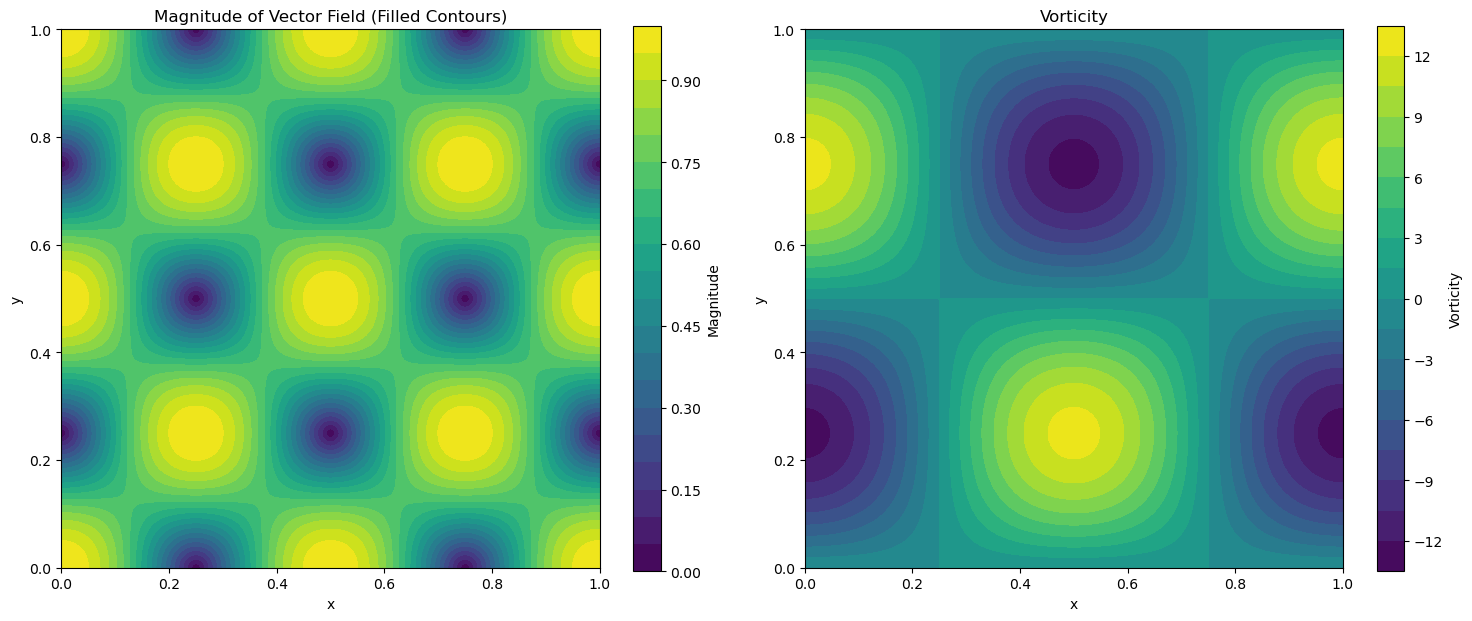

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.tri import Triangulation
import matplotlib.tri as tri

# Calculate the magnitude of the vector field
magnitude = np.sqrt(function_values_x**2 + function_values_y**2)

# Extract x and y coordinates from dof_coordinates
x_coords = dof_coordinates[:, 0]
y_coords = dof_coordinates[:, 1]

# Create triangulation for irregular grid
triang = Triangulation(x_coords, y_coords)

# Create the contour plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Filled contour plot
contour_filled = ax1.tricontourf(triang, magnitude, levels=20, cmap='viridis')
ax1.set_title('Magnitude of Vector Field (Filled Contours)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal')
plt.colorbar(contour_filled, ax=ax1, label='Magnitude')

print(magnitude)
print(vorticity_values)
print(np.max(vorticity_values))
print(np.min(vorticity_values))

# Plot 1: Filled contour plot
vorticity_filled = ax2.tricontourf(triang, vorticity_values, levels=20, cmap='viridis')
ax2.set_title('Vorticity')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_aspect('equal')
plt.colorbar(vorticity_filled, ax=ax2, label='Vorticity')

plt.tight_layout()
plt.show()




In [24]:
import gmsh

# Initialize gmsh
gmsh.initialize()

# Create a new model
gmsh.model.add("square_mesh")

# Define square corners (side length = 1)
side_length = 1.0

# Add points for the square corners
point1 = gmsh.model.geo.addPoint(0.0, 0.0, 0.0)
point2 = gmsh.model.geo.addPoint(side_length, 0.0, 0.0)
point3 = gmsh.model.geo.addPoint(side_length, side_length, 0.0)
point4 = gmsh.model.geo.addPoint(0.0, side_length, 0.0)

# Create lines connecting the points
line1 = gmsh.model.geo.addLine(point1, point2)
line2 = gmsh.model.geo.addLine(point2, point3)
line3 = gmsh.model.geo.addLine(point3, point4)
line4 = gmsh.model.geo.addLine(point4, point1)

# Create a curve loop and surface
curve_loop = gmsh.model.geo.addCurveLoop([line1, line2, line3, line4])
surface = gmsh.model.geo.addPlaneSurface([curve_loop])
gmsh.model.geo.synchronize()
gmsh.model.addPhysicalGroup(2, [surface], 1)  # Add physical group for the surface
gmsh.model.addPhysicalGroup(1, [line1, line2, line3, line4], 2) 


# Set mesh size (smaller value = finer mesh)
mesh_size = 0.01
gmsh.model.geo.mesh.setSize([(0, point1), (0, point2), (0, point3), (0, point4)], mesh_size)

# Synchronize the model
gmsh.model.geo.synchronize()

gmsh.option.setNumber("Mesh.MshFileVersion", 2)

# Generate 2D mesh
gmsh.model.mesh.generate(2)
# Optional: Save the mesh to a file
gmsh.write("square_mesh.msh")
